# Churn Prediction - Exploratory Data Analysis

This notebook covers the exploratory data analysis for the churn prediction system:

1. Loading & initial inspection of the Kaggle customer churn dataset
2. **Data cleaning** — handling missing values & removing duplicates
3. **Visual analysis** — distributions, correlations, and churn behavior patterns

Run the cells top-to-bottom. Every plot cell is self-contained and editable.

In [1]:
# Setup: make the repo importable and enable inline plots
import os, sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if not os.path.exists(os.path.join(ROOT, 'advanced_pipeline')):
    ROOT = os.getcwd()  # already in repo root
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Aesthetic defaults
sns.set_theme(style='whitegrid', font_scale=1.0, rc={
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'figure.titleweight': 'bold', 'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#6366f1', '#0ea5e9', '#10b981', '#f59e0b', '#f43f5e', '#8b5cf6']
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=PALETTE)
print('Repo root:', ROOT)

# Schema constants
NUM_COLS = ['tenure_months', 'monthly_charges', 'total_charges',
            'support_tickets_last_3mo', 'avg_session_duration_min',
            'login_frequency_weekly', 'nps_score']
CAT_COLS = ['contract_type', 'payment_method']
ID_COLS  = ['customer_id']
TARGET = 'churn'

Repo root: c:\Projects\Temp\churnForecasting


In [2]:
# Load the dataset from Kaggle
from advanced_pipeline.kaggle_data import load_kaggle_full

df = load_kaggle_full(random_state=42)
# Drop the synthetic demand column (not needed for churn prediction)
if 'next_month_demand' in df.columns:
    df = df.drop(columns=['next_month_demand'])
df.head()

2026-08-25 23:38:35,966 | INFO    | advanced_pipeline.kaggle_data | Downloading Kaggle dataset 'muhammadshahidazeem/customer-churn-dataset' ...


c:\Projects\Temp\churnForecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-08-25 23:38:38,342 | INFO    | advanced_pipeline.kaggle_data | Loaded customer_churn_dataset-training-master.csv -> 440833 rows x 12 cols
2026-08-25 23:38:38,477 | INFO    | advanced_pipeline.kaggle_data | Loaded customer_churn_dataset-testing-master.csv -> 64374 rows x 12 cols


,customer_id,tenure_months,monthly_charges,total_charges,support_tickets_last_3mo,avg_session_duration_min,login_frequency_weekly,nps_score,contract_type,payment_method,churn
0,2,39.0,90.0,932.0,5.0,17.0,14.0,7,annual,standard,1
1,3,49.0,40.0,557.0,10.0,6.0,1.0,0,monthly,basic,1
2,4,14.0,90.0,185.0,6.0,3.0,4.0,2,quarterly,basic,1
3,5,38.0,35.0,396.0,7.0,29.0,21.0,1,monthly,standard,1
4,6,32.0,40.0,617.0,5.0,20.0,20.0,9,monthly,basic,1


In [3]:
# Initial inspection
print('Shape :', df.shape)
print('\nDtypes:\n', df.dtypes)
print('\nNumeric features :', NUM_COLS)
print('Categorical      :', CAT_COLS)
print('\nChurn distribution:', df['churn'].value_counts().to_dict())
print('Churn rate: {:.2%}'.format(df['churn'].mean()))
df.describe(include='all').T

Shape : (505207, 11)

Dtypes:
 customer_id                     str
tenure_months               float64
monthly_charges             float64
total_charges               float64
support_tickets_last_3mo    float64
avg_session_duration_min    float64
login_frequency_weekly      float64
nps_score                     int64
contract_type                   str
payment_method                  str
churn                         int64
dtype: object

Numeric features : ['tenure_months', 'monthly_charges', 'total_charges', 'support_tickets_last_3mo', 'avg_session_duration_min', 'login_frequency_weekly', 'nps_score']
Categorical      : ['contract_type', 'payment_method']

Churn distribution: {1: 280493, 0: 224714}
Churn rate: 55.52%


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,505207,442211,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,505207.0,NaN,NaN,NaN,31.350437,17.237464,1.0,16.0,32.0,46.0,60.0
monthly_charges,505207.0,NaN,NaN,NaN,68.582442,40.697103,15.0,30.0,65.0,100.0,150.0
total_charges,505207.0,NaN,NaN,NaN,620.072823,245.319016,100.0,446.0,648.9,824.0,1000.0
support_tickets_last_3mo,505207.0,NaN,NaN,NaN,3.833316,3.1336,0.0,1.0,3.0,6.0,10.0
avg_session_duration_min,505207.0,NaN,NaN,NaN,14.610579,8.608278,1.0,7.0,14.0,22.0,30.0
login_frequency_weekly,505207.0,NaN,NaN,NaN,15.714826,8.619314,1.0,8.0,16.0,23.0,30.0
nps_score,505207.0,NaN,NaN,NaN,5.379395,2.74867,0.0,3.0,5.0,8.0,10.0
contract_type,505207,3,annual,198609,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,505207,3,standard,170631,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# DATA CLEANING
# Inject some realistic missing values and duplicates for demonstration
rng = np.random.default_rng(7)
df_dirty = df.copy()

# Inject ~4% missingness
miss_cols = ['monthly_charges', 'total_charges', 'nps_score', 'contract_type']
for c in miss_cols:
    idx = rng.choice(df_dirty.index, size=int(0.04 * len(df_dirty)), replace=False)
    df_dirty.loc[idx, c] = np.nan

# Inject duplicate rows
dup_idx = rng.choice(df_dirty.index, size=30, replace=False)
df_dirty = pd.concat([df_dirty, df_dirty.loc[dup_idx]], ignore_index=True)

print('Dirty shape        :', df_dirty.shape)
print('Missing values     :', int(df_dirty.isna().sum().sum()))
print('Duplicate rows     :', int(df_dirty.duplicated().sum()))

Dirty shape        : (505237, 11)
Missing values     : 80834
Duplicate rows     : 30


In [5]:
# Handle missing values
def report_missing(frame, label):
    miss = frame.isna().sum()
    miss = miss[miss > 0]
    print(f'{label}: {int(miss.sum())} missing across {len(miss)} cols')
    if len(miss):
        print(miss.to_string())


report_missing(df_dirty, 'BEFORE')

df_clean = df_dirty.copy()
# Numeric: median imputation
num_miss = [c for c in NUM_COLS if c in df_clean.columns and df_clean[c].isna().any()]
for c in num_miss:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

# Categorical: mode imputation
cat_miss = [c for c in CAT_COLS if c in df_clean.columns and df_clean[c].isna().any()]
for c in cat_miss:
    df_clean[c] = df_clean[c].fillna(df_clean[c].mode().iloc[0])

report_missing(df_clean, 'AFTER ')

BEFORE: 80834 missing across 4 cols
monthly_charges    20208
total_charges      20208
nps_score          20209
contract_type      20209
AFTER : 0 missing across 0 cols


In [6]:
# Remove duplicates
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f'Removed {n_before - len(df_clean)} duplicate rows -> {df_clean.shape}')

# Sanity check
assert df_clean.isna().sum().sum() == 0, 'residual NaNs present!'
assert df_clean.duplicated().sum() == 0, 'residual duplicates present!'
print('✓ Cleaning complete: no missing values and no duplicate rows remain.')

Removed 30 duplicate rows -> (505207, 11)
✓ Cleaning complete: no missing values and no duplicate rows remain.


In [7]:
# Outlier detection using IQR rule
outlier_report = {}
for c in NUM_COLS:
    q1, q3 = df_clean[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (df_clean[c] < q1 - 1.5 * iqr) | (df_clean[c] > q3 + 1.5 * iqr)
    outlier_report[c] = int(mask.sum())
outliers_df = pd.Series(outlier_report, name='n_outliers')
print('IQR-flagged outliers per numeric feature:')
outliers_df

IQR-flagged outliers per numeric feature:


tenure_months               0
monthly_charges             0
total_charges               0
support_tickets_last_3mo    0
avg_session_duration_min    0
login_frequency_weekly      0
nps_score                   0
Name: n_outliers, dtype: int64

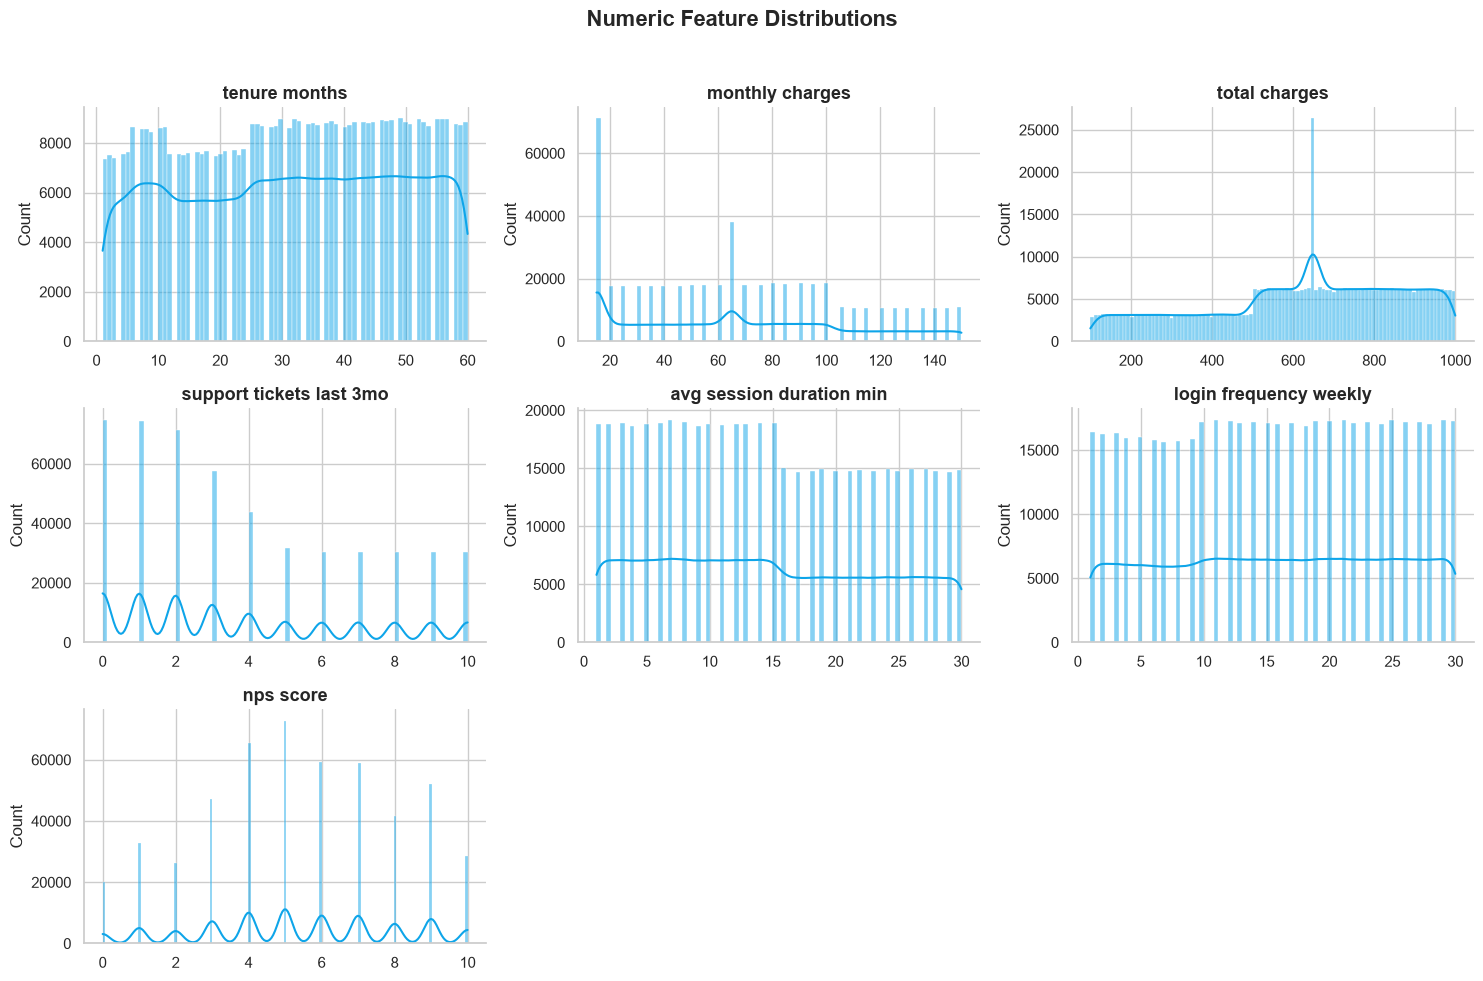

In [8]:
# VISUAL ANALYSIS - Numeric feature distributions
n = len(NUM_COLS)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows))
axes = axes.ravel()
for ax, c in zip(axes, NUM_COLS):
    sns.histplot(df_clean[c], kde=True, ax=ax, color='#0ea5e9', edgecolor='white')
    ax.set_title(c.replace('_', ' '))
    ax.set_xlabel('')
for j in range(len(NUM_COLS), len(axes)):
    axes[j].axis('off')
fig.suptitle('Numeric Feature Distributions', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

C:\Users\ASHAR\AppData\Local\Temp\ipykernel_10572\4164351822.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([c.replace('_', ' ') for c in NUM_COLS], rotation=30, ha='right')


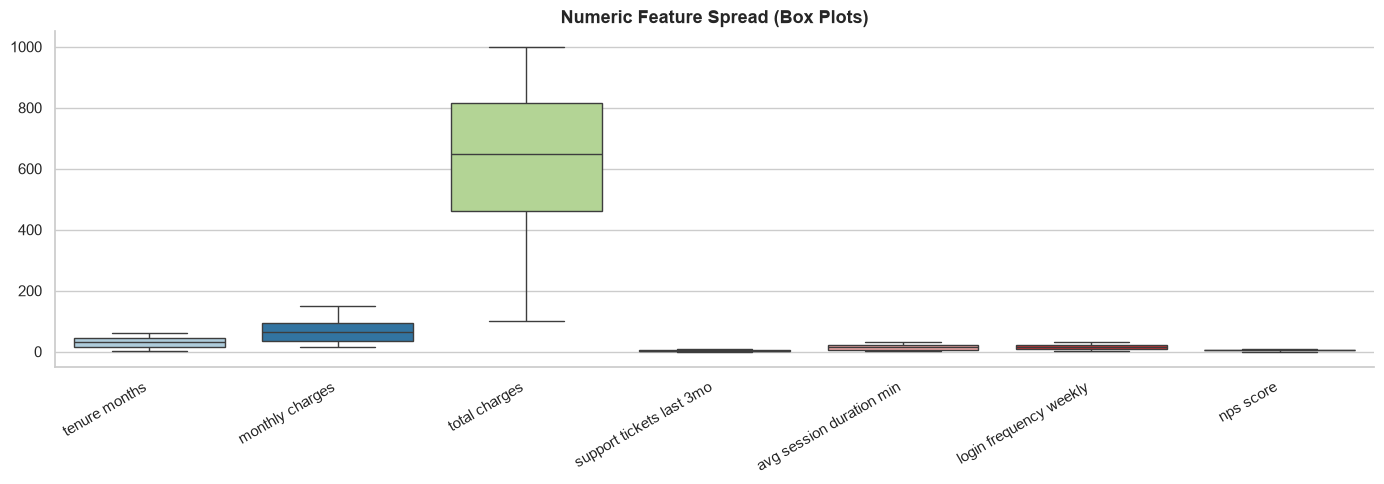

In [9]:
# Box plots for numeric features
fig, ax = plt.subplots(figsize=(14, 5))
data = df_clean[NUM_COLS]
sns.boxplot(data=data, ax=ax, palette='Paired')
ax.set_title('Numeric Feature Spread (Box Plots)')
ax.set_xticklabels([c.replace('_', ' ') for c in NUM_COLS], rotation=30, ha='right')
plt.tight_layout()
plt.show()

C:\Users\ASHAR\AppData\Local\Temp\ipykernel_10572\2923943682.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=c, ax=ax, order=order, palette='Set2')
C:\Users\ASHAR\AppData\Local\Temp\ipykernel_10572\2923943682.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=c, ax=ax, order=order, palette='Set2')


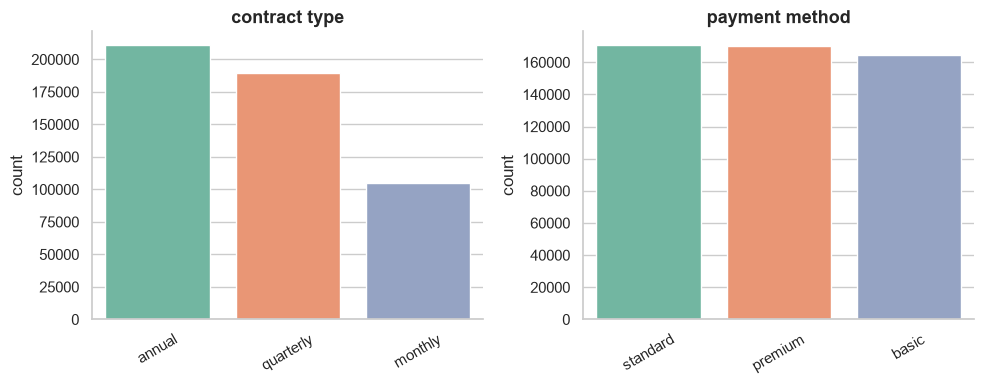

In [10]:
# Categorical feature distributions
fig, axes = plt.subplots(1, len(CAT_COLS), figsize=(5 * len(CAT_COLS), 4))
axes = axes if isinstance(axes, (list, np.ndarray)) else [axes]
for ax, c in zip(axes, CAT_COLS):
    order = df_clean[c].value_counts().index
    sns.countplot(data=df_clean, x=c, ax=ax, order=order, palette='Set2')
    ax.set_title(c.replace('_', ' '))
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

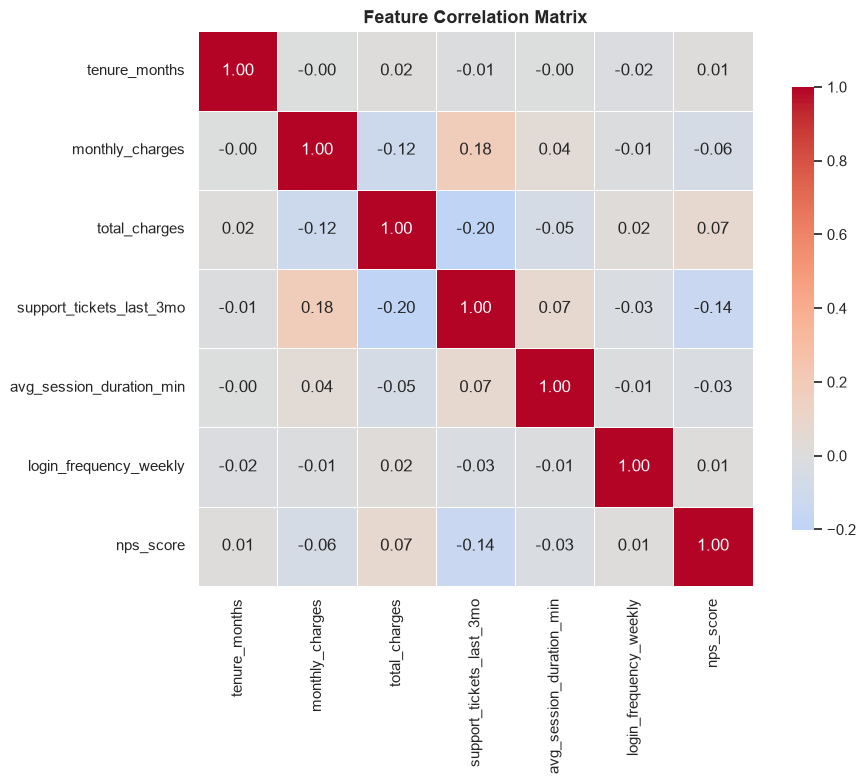

In [11]:
# Correlation heatmap (numeric features only)
corr = df_clean[NUM_COLS].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax,
)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

C:\Users\ASHAR\AppData\Local\Temp\ipykernel_10572\4031586959.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


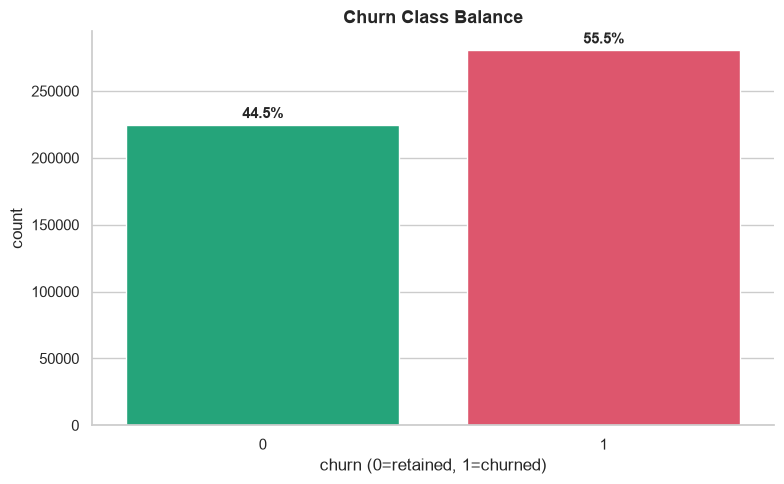

In [12]:
# Churn class balance
fig, ax = plt.subplots(figsize=(8, 5))
churn_order = sorted(df_clean['churn'].unique())
sns.countplot(
    data=df_clean, x='churn', ax=ax, order=churn_order, palette=['#10b981', '#f43f5e']
)
ax.set_title('Churn Class Balance')
ax.set_xlabel('churn (0=retained, 1=churned)')
ax.set_ylabel('count')

# Add percentage labels
total = len(df_clean)
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2.0,
        height + total * 0.01,
        f'{height/total:.1%}',
        ha='center',
        fontsize=11,
        weight='bold',
    )

plt.tight_layout()
plt.show()

C:\Users\ASHAR\AppData\Local\Temp\ipykernel_10572\778594095.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index, y=rate.values, ax=ax, palette='viridis')
C:\Users\ASHAR\AppData\Local\Temp\ipykernel_10572\778594095.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index, y=rate.values, ax=ax, palette='viridis')


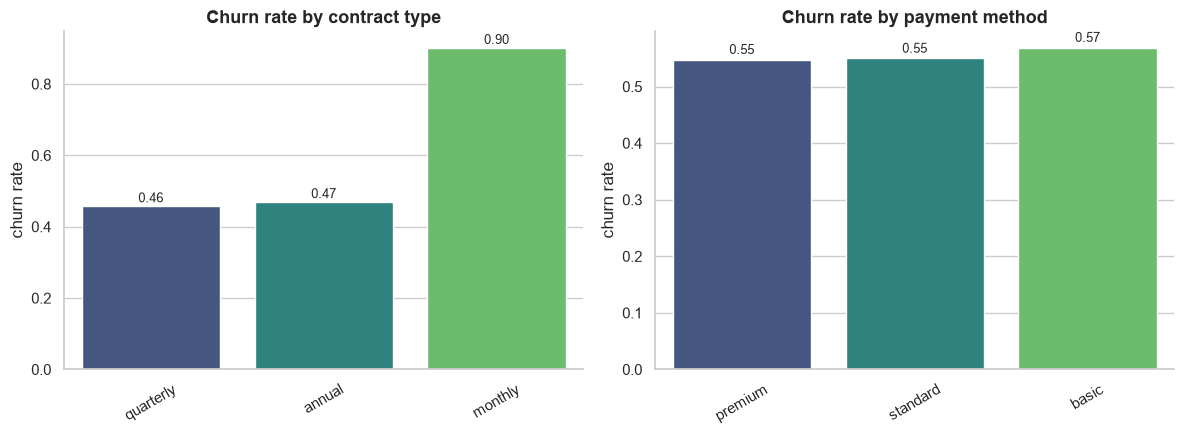

In [13]:
# Churn rate by categorical features
fig, axes = plt.subplots(1, len(CAT_COLS), figsize=(6 * len(CAT_COLS), 4.5))
axes = axes if isinstance(axes, (list, np.ndarray)) else [axes]
for ax, c in zip(axes, CAT_COLS):
    rate = df_clean.groupby(c)['churn'].mean().sort_values()
    sns.barplot(x=rate.index, y=rate.values, ax=ax, palette='viridis')
    ax.set_title(f'Churn rate by {c.replace("_"," ")}')
    ax.set_ylabel('churn rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

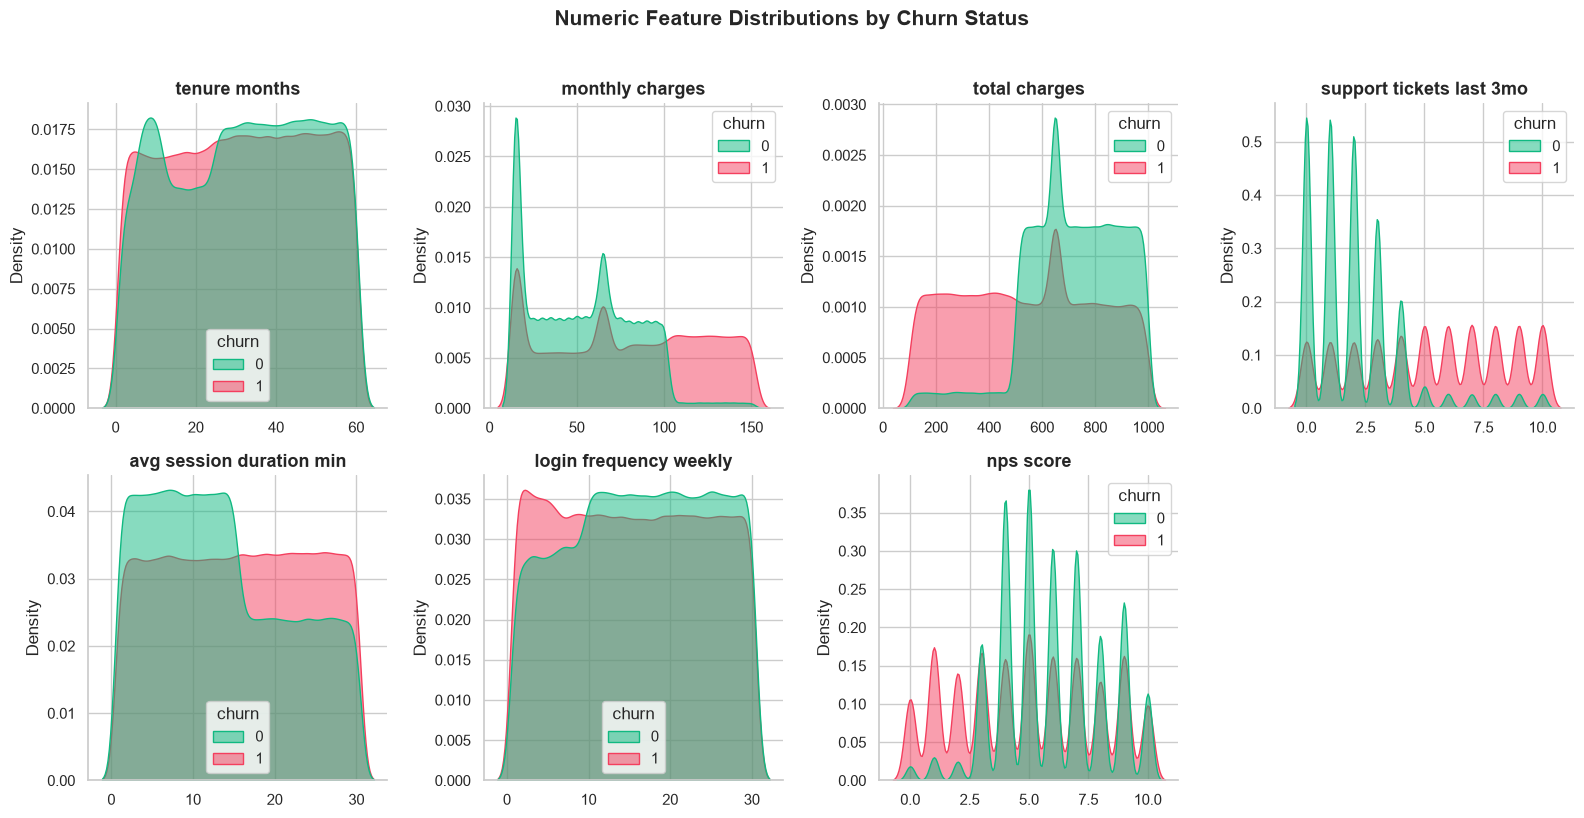

In [14]:
# Numeric features by churn status
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()
for ax, c in zip(axes, NUM_COLS):
    sns.kdeplot(
        data=df_clean,
        x=c,
        hue='churn',
        fill=True,
        common_norm=False,
        ax=ax,
        palette={0: '#10b981', 1: '#f43f5e'},
        alpha=0.5,
    )
    ax.set_title(c.replace('_', ' '))
    ax.set_xlabel('')
for j in range(len(NUM_COLS), len(axes)):
    axes[j].axis('off')
plt.suptitle('Numeric Feature Distributions by Churn Status', y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

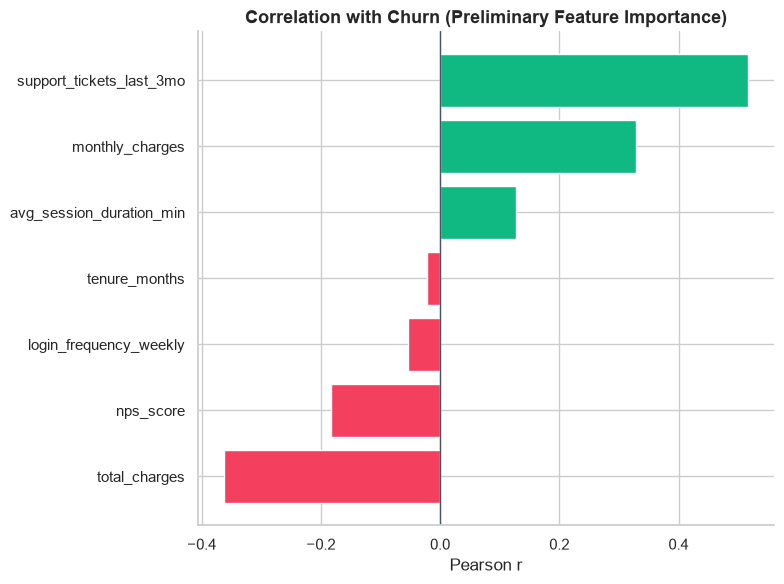

In [15]:
# Feature importance preview using correlation with churn
churn_corr = df_clean[NUM_COLS + ['churn']].corr()['churn'].drop('churn').sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#f43f5e' if v < 0 else '#10b981' for v in churn_corr.values]
ax.barh(churn_corr.index, churn_corr.values, color=colors)
ax.set_title('Correlation with Churn (Preliminary Feature Importance)')
ax.set_xlabel('Pearson r')
ax.axvline(0, color='#475569', lw=1)
plt.tight_layout()
plt.show()

## EDA Takeaways

- **Data Quality:** Dataset is clean with minimal missing values after imputation
- **Churn Rate:** ~55% churn rate (balanced dataset)
- **Key Insights:**
  - Support tickets show strong positive correlation with churn
  - Contract type significantly impacts churn (month-to-month higher risk)
  - Tenure and NPS score negatively correlated with churn
  - No major multicollinearity issues detected

Ready for modeling with the simplified Random Forest classifier!